<div>
    <h1 align="center"> Endodontic Surgery </h1>
    <h3 align="center"> Custom Data Generator for Orthopantomogram (OPG) Dental X-ray Images</h1>
    <h5 align="center"> Seyyed Hossein Hosseini</h5>
</div>

## Setup

In [ ]:
!pip install pydicom

In [ ]:
!pip install split-folders[full]

In [ ]:
!pip install -U gdown

In [4]:
!pip install visualkeras

In [ ]:
import gdown
import os
import glob
import pydicom
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set(style="whitegrid")
sns.set_context("paper")
import tensorflow as tf
import random as python_random
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental.preprocessing import CenterCrop
from scipy import ndimage
import splitfolders

# obtaining reproducible results
SEED = 2023
os.environ['PYTHONHASHSEED'] = str(SEED)
# The code below is necessary for starting Numpy generated random numbers
np.random.seed(SEED)
# The code below is necessary for starting core Python generated random numbers
python_random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
print(tf.__version__)

2.12.0


**CPU**

In [ ]:
# Default strategy works on CPU 
strategy = tf.distribute.get_strategy()
print('Running on CPU')
print("Number of accelerators: ", strategy.num_replicas_in_sync)

Running on CPU
Number of accelerators:  1


**GPU**

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Thu May 25 09:26:22 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   46C    P8    10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

**TPU**

In [ ]:
# Checking whether we can connect to TPU or not
# detecting TPU
try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
except ValueError: # If TPU not found
  raise BaseException('ERROR: Not connected to a TPU runtime.')

# TPU is a distributed training processor and is not single-core like a traditional CPU
# Selecting appropriate distribution strategy
tf.config.experimental_connect_to_cluster(tpu)
# TPU initialization has to be at the beginning.
tf.tpu.experimental.initialize_tpu_system(tpu)
print("All devices: ", tf.config.list_logical_devices('TPU'))

tpu_strategy = tf.distribute.TPUStrategy(tpu) 
print("Number of accelerators: ", tpu_strategy.num_replicas_in_sync)

Running on TPU  ['10.27.176.26:8470']
All devices:  [LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:0', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:1', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:2', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:3', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:4', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:5', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:6', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:7', device_type='TPU')]
Number of accelerators:  8


## Preprocessing

In [ ]:
# downloading the first part of the data(iaaa-data_v2.zip)
!gdown 1-PjJzxu1as1DkEY6ZU0NjNqqTvCgiP4d
#!mv /content/iaaa-data_v2.zip /content/drive/MyDrive/endodontic/data

In [ ]:
# downloading the second part of the data(iaaa-data-v3.zip)
!gdown 1j8JrLLv0KeSfbzP93_6LH8nZcWRchTIb

In [ ]:
# downloading the third part of the data(data-v3.zip)
!gdown 1Rc4zrLHjvTYR-1szxpEe1R_259X2l9YQ
# now there are 3 zip files (3 parts of data) in content directory(disk)

In [ ]:
# inflating the 'data' directory with the unzipped files
!unzip /content/iaaa-data_v2.zip -d /content/drive/MyDrive/endodontic/data

In [ ]:
!unzip /content/iaaa-data-v3.zip -d /content/drive/MyDrive/endodontic/data

In [ ]:
!unzip /content/data-v3.zip -d /content/drive/MyDrive/endodontic/data

#### Transfering files from DICOM folder to normal and abnormal folders

In [ ]:
# creating 'DICOM_Data' folder
os.mkdir('/content/drive/MyDrive/endodontic/data/DICOM_Data')
# creating 2 folders in 'DICOM_Data' folder: one for normal and another for abnormal class
os.mkdir('/content/drive/MyDrive/endodontic/data/DICOM_Data/normal')
os.mkdir('/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal')

- **Data Part 1:**

In [ ]:
dcm_dir1 = '/content/drive/MyDrive/endodontic/data/content/iaaa-data/DICOM/'
label_dir1 = '/content/drive/MyDrive/endodontic/data/content/iaaa-data/labels.csv'

In [ ]:
df1 = pd.read_csv(label_dir1)
print(df1.shape)
print(df1.Label.unique())
df1.head()

(509, 3)
['normal' 'abnormal']


,Unnamed: 0,SOPInstanceUID,Label
0,0,1.2.246.512.1002.1058214001.1267878993.1650415...,normal
1,1,2.25.4669378111734520225376815262123197003,normal
2,2,1.2.246.512.1.2.0.4.397070732735579.1755416012...,normal
3,3,2.25.253986991488355213316410237483051286906,normal
4,4,2.25.61269522713157549205486841880699641492,normal


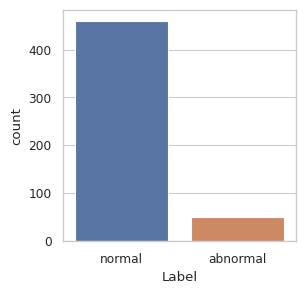

In [ ]:
plt.figure(figsize = (3, 3))
sns.countplot(x = df1['Label']);

In [ ]:
a = df1[df1['SOPInstanceUID']=='2.25.253986991488355213316410237483051286906'].index.values
print(a)
df1.iloc[a[0], 2]

[3]


'normal'

In [ ]:
# Transfering files from 'DICOM' folder to 'normal' and 'abnormal' folders
file_names = os.listdir(dcm_dir1)
# fetching all files
for f in file_names:  
    # Load the DICOM file
    file_path = os.path.join(dcm_dir1, f)
    dcm_img = pydicom.dcmread(file_path)
    s = dcm_img.SOPInstanceUID
    r = df1[df1['SOPInstanceUID']==s].index.values
    source = dcm_dir1+f
    if df1.iloc[r[0], 2] == 'normal':
        # transfering normal images to normal folder
        shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/normal')
    else:
        # transfering abnormal images to abnormal folder
        shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal')

- **Data Part 2:**

In [ ]:
dcm_dir2 = '/content/drive/MyDrive/endodontic/data/iaaa-data-v3/DICOM/'
label_dir2 = '/content/drive/MyDrive/endodontic/data/iaaa-data-v3/labels.csv'

In [ ]:
df2 = pd.read_csv(label_dir2)
print(df2.shape)
print(df2.Label.unique())
df2.head()

(334, 2)
['normal' 'abnormal']


,SOPInstanceUID,Label
0,2.25.282284409759598143141584841229173395105,normal
1,1.2.246.512.1002.2619269004.1106409608.5897144...,normal
2,1.2.246.512.1002.3453311573.1115640134.1612280...,normal
3,2.25.86084165035122156986727255145476652919,normal
4,2.25.163313489094622786647561822562837612051,normal


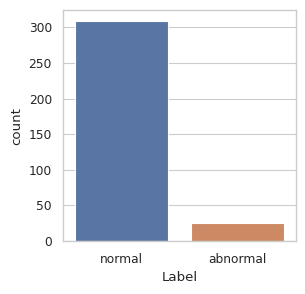

In [ ]:
plt.figure(figsize = (3, 3))
sns.countplot(x = df2['Label']);

In [ ]:
a = df2[df2['SOPInstanceUID']=='2.25.163313489094622786647561822562837612051'].index.values
print(a)
df2.iloc[a[0], 1]

[4]


'normal'

In [ ]:
# Transfering files from 'DICOM' folder to 'normal' and 'abnormal' folders
file_names = os.listdir(dcm_dir2)
# fetching all files
for f in file_names:  
    # Load the DICOM file
    file_path = os.path.join(dcm_dir2, f)
    dcm_img = pydicom.dcmread(file_path)
    s = dcm_img.SOPInstanceUID
    r = df2[df2['SOPInstanceUID']==s].index.values
    source = dcm_dir2+f
    if df2.iloc[r[0], 1] == 'normal':
        # transfering normal images to normal folder
        shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/normal')
    else:
        # transfering abnormal images to abnormal folder
        shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal')

- **Data Part 3-1:**

In [ ]:
dcm_dir3 = '/content/drive/MyDrive/endodontic/data/iaaa_dental_labeler6_dup/DICOM/'
label_dir3 = '/content/drive/MyDrive/endodontic/data/iaaa_dental_labeler6_dup/labels.csv'

In [ ]:
df3 = pd.read_csv(label_dir3)
print(df3.shape)
print(df3.Label.unique())
df3.head()

(266, 2)
['normal' 'abnormal']


,SOPInstanceUID,Label
0,2.25.5909647824625387033599618422552575781,normal
1,2.25.327384166064930452382568937934620248813,normal
2,1.2.246.512.1002.1757753761.1102668463.1582765...,normal
3,1.2.246.512.1002.4117495487.1307938565.1277028...,normal
4,1.2.246.512.1002.3172221204.1221093610.1120958...,normal


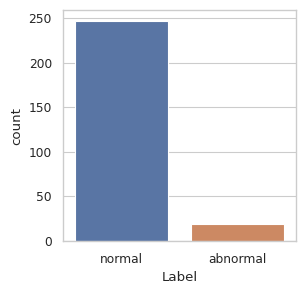

In [ ]:
plt.figure(figsize = (3, 3))
sns.countplot(x = df3['Label']);

In [ ]:
a = df3[df3['SOPInstanceUID']=='2.25.5909647824625387033599618422552575781'].index.values
print(a)
df3.iloc[a[0], 1]

[0]


'normal'

In [ ]:
# Transfering files from 'DICOM' folder to 'normal' and 'abnormal' folders
file_names = os.listdir(dcm_dir3)
# fetching all files
for f in file_names:  
    # Load the DICOM file
    file_path = os.path.join(dcm_dir3, f)
    dcm_img = pydicom.dcmread(file_path)
    s = dcm_img.SOPInstanceUID
    r = df3[df3['SOPInstanceUID']==s].index.values
    source = dcm_dir3+f
    if df3.iloc[r[0], 1] == 'normal':
        # transfering normal images to normal folder
        shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/normal')
    else:
        # transfering abnormal images to abnormal folder
        shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal')

- **Data Part 3-2:**

In [ ]:
dcm_dir4 = '/content/drive/MyDrive/endodontic/data/iaaa_dental_labeler7_dup/DICOM/'
label_dir4 = '/content/drive/MyDrive/endodontic/data/iaaa_dental_labeler7_dup/labels.csv'

In [ ]:
df4 = pd.read_csv(label_dir4)
print(df4.shape)
print(df4.Label.unique())
df4.head(7)

(275, 2)
['normal' 'abnormal']


,SOPInstanceUID,Label
0,1.2.246.512.1002.2673929357.1091365365.1719138...,normal
1,1.2.246.512.1002.2250267112.1248382323.3484622...,normal
2,1.2.246.512.1002.817417347.1177550105.80145350...,normal
3,1.2.246.512.1002.1030588087.1105439860.7586513...,normal
4,1.2.246.512.1002.2011948557.1293225468.7354021...,normal
5,2.25.151902206152692281405458202515109920241,normal
6,2.25.164415246667567080575502192829629702263,abnormal


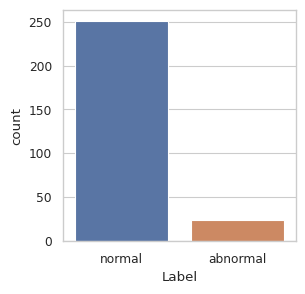

In [ ]:
plt.figure(figsize = (3, 3))
sns.countplot(x = df4['Label']);

In [ ]:
a = df4[df4['SOPInstanceUID']=='2.25.151902206152692281405458202515109920241'].index.values
print(a)
df4.iloc[a[0], 1]

[5]


'normal'

In [ ]:
# Transfering files from 'DICOM' folder to 'normal' and 'abnormal' folders
file_names = os.listdir(dcm_dir4)
# fetching all files
for f in file_names:  
    # Load the DICOM file
    file_path = os.path.join(dcm_dir4, f)
    dcm_img = pydicom.dcmread(file_path)
    s = dcm_img.SOPInstanceUID
    r = df4[df4['SOPInstanceUID']==s].index.values
    source = dcm_dir4+f
    if df4.iloc[r[0], 1] == 'normal':
        # transfering normal images to normal folder
        # checking duplicated data
        dst_normal = '/content/drive/MyDrive/endodontic/data/DICOM_Data/normal/' + f
        if not os.path.exists(dst_normal):
          shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/normal')
    else:
        # transfering abnormal images to abnormal folder
        # checking duplicated data
        dst_abnormal = '/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal/' + f
        if not os.path.exists(dst_abnormal):
          shutil.move(source, '/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal')

# there are 4 dulicate data(3 normal samples and 1 abnormal sample)

- **All of data:**

In [ ]:
DATA_DIRECT = '/content/drive/MyDrive/endodontic/data/DICOM_Data/'
print( os.listdir(DATA_DIRECT))

['normal', 'abnormal']


In [ ]:
# class-imbalanced dataset 
print(f"Number of normal samples : {len(os.listdir(DATA_DIRECT+'normal'))}")
print(f"Number of abnormal samples: {len(os.listdir(DATA_DIRECT+'abnormal'))}")

Number of normal samples : 1264
Number of abnormal samples: 116


### Data Visualization

In [ ]:
# this returns a 'list' in specified pattern
trn_normal_names = glob.glob('/content/drive/MyDrive/endodontic/data/DICOM_Data/normal/*.dcm')
print(trn_normal_names[:2])
trn_abnormal_names = glob.glob('/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal/*.dcm')  
print(trn_abnormal_names[:2])

['/content/drive/MyDrive/endodontic/data/DICOM_Data/normal/2.25.261552588437645194939542265733484047835.dcm', '/content/drive/MyDrive/endodontic/data/DICOM_Data/normal/1.2.246.512.1002.1808552602.1149237904.11486853308802758541.dcm']
['/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal/1.2.246.512.1002.4046933793.1329774659.16304224041255670174.dcm', '/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal/1.2.246.512.1.2.0.4.298654083137790.16721130216.20230104115701.dcm']


In [ ]:
# investigating one normal sample
file_path = trn_normal_names[0]
dcm_image = pydicom.dcmread(file_path)
print(dcm_image)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 172
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 2.25.261552588437645194939542265733484047835
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.40.0.13.1.1
(0002, 0013) Implementation Version Name         SH: 'dcm4che-2.0'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', '']
(0008, 0016) SOP Class UID                       UI: CT Image Storage
(0008, 0018) SOP Instance UID                    UI: 2.25.261552588437645194939542265733484047835
(0008, 0020) Study Date                          DA: '20230114'
(0008, 0021) Ser

In [ ]:
print(type(dcm_image))
print(dcm_image.SOPInstanceUID)
image = dcm_image.pixel_array
print(image.shape)
print(type(image))
print(image.dtype)

<class 'pydicom.dataset.FileDataset'>
2.25.261552588437645194939542265733484047835
(1536, 3208)
<class 'numpy.ndarray'>
uint16


In [ ]:
image

array([[65504, 65504, 65504, ..., 65520, 65520, 65520],
       [65520, 65520, 65504, ..., 65520, 65520, 65520],
       [65520, 65504, 65504, ..., 65520, 65520, 65520],
       ...,
       [10160, 42336, 65408, ..., 65520, 65520, 65520],
       [ 9872, 11584, 43920, ..., 65520, 65520, 65520],
       [16032, 16032, 16336, ..., 65520, 65520, 65520]], dtype=uint16)

In [ ]:
print(image.min())
print(image.max())

0
65520


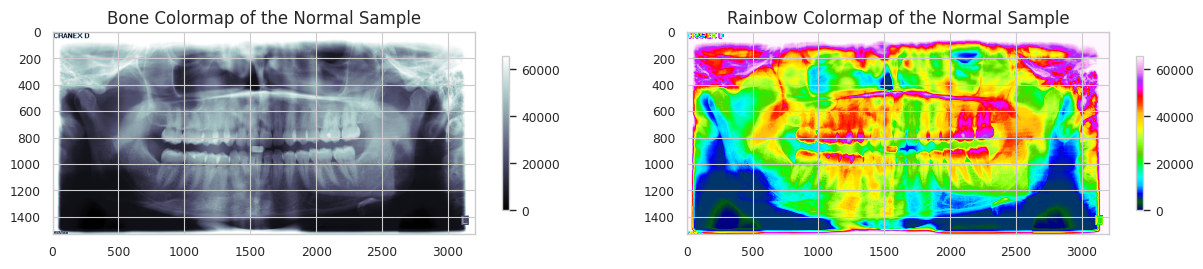

In [ ]:
# visualizing the normal sample by two different colormaps
plt.figure(figsize = (15, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='bone')
plt.colorbar(shrink=0.2)
plt.title("Bone Colormap of the Normal Sample", fontsize=12)

plt.subplot(1, 2, 2)
# rainbow colormap to fully utilize computer's ability to display colors
plt.imshow(image, cmap=plt.cm.gist_ncar)
plt.colorbar(shrink=0.2)
plt.title("Rainbow Colormap of the Normal Sample", fontsize=12);

(array([ 36466.,  16015.,  19167.,  20758.,  41969., 380280.,  90819.,
         61023.,  53932.,  46933.,  46157.,  50363.,  60363.,  66585.,
         62983.,  60377.,  57095.,  57946.,  62520.,  62933.,  69252.,
         69172.,  73151.,  82304.,  81818.,  77580.,  77691.,  75833.,
         82833.,  82506.,  94868.,  97041., 101147.,  94954.,  94538.,
         90108.,  88970.,  89272.,  86737.,  80429.,  84366.,  81733.,
         91843.,  90119.,  85664.,  72345.,  73413.,  63833.,  62581.,
         54610.,  54475.,  46311.,  48734.,  40745.,  45788.,  45705.,
         43407.,  37669.,  36812.,  35016.,  33693.,  30996.,  28032.,
         23512.,  24406.,  22066.,  22134.,  18980.,  16983., 466629.]),
 array([    0.,   936.,  1872.,  2808.,  3744.,  4680.,  5616.,  6552.,
         7488.,  8424.,  9360., 10296., 11232., 12168., 13104., 14040.,
        14976., 15912., 16848., 17784., 18720., 19656., 20592., 21528.,
        22464., 23400., 24336., 25272., 26208., 27144., 28080., 29016.,


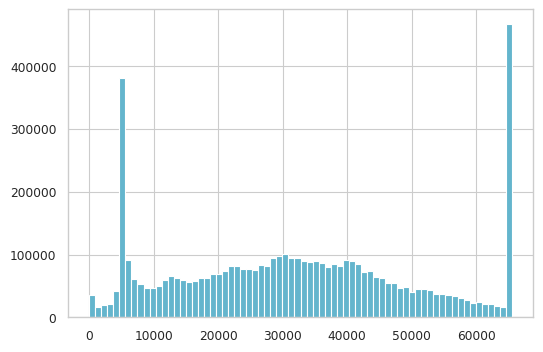

In [ ]:
# plotting histogram
plt.figure(figsize=(6,4))
plt.hist(image.flatten(), bins=70, color='c')

In [ ]:
len(np.unique(image))

1597

(array([ 36466.,  16015.,  19167.,  20758.,  41969., 380280.,  90819.,
         61023.,  53932.,  46933.,  46157.,  50363.,  60363.,  66585.,
         62983.,  60377.,  57095.,  57946.,  62520.,  62933.,  69252.,
         69172.,  73151.,  82304.,  81818.,  77580.,  77691.,  75833.,
         82833.,  82506.,  94868.,  97041., 101147.,  94954.,  94538.,
         90108.,  94929.,  83313.,  86737.,  74553.,  90242.,  81733.,
         85091.,  96871.,  85664.,  72345.,  73413.,  58648.,  67766.,
         54610.,  54475.,  46311.,  48734.,  40745.,  45788.,  45705.,
         43407.,  37669.,  36812.,  35016.,  36937.,  27752.,  28032.,
         23512.,  24406.,  22066.,  20004.,  21110.,  16983., 466629.]),
 array([0.        , 0.01428223, 0.02856445, 0.04284668, 0.05712891,
        0.07141113, 0.08569336, 0.09997559, 0.11425781, 0.12854004,
        0.14282227, 0.15710449, 0.17138672, 0.18566895, 0.19995117,
        0.2142334 , 0.22851562, 0.24279785, 0.25708008, 0.27148438,
        0.285644

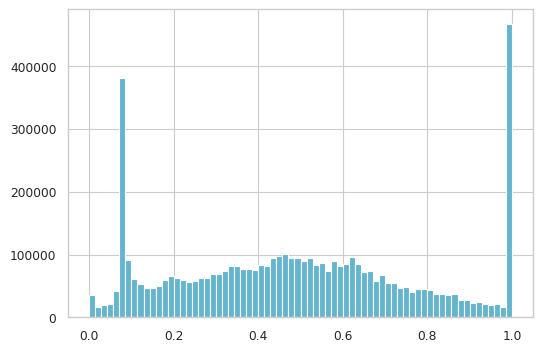

In [ ]:
# normalizing the image
normalized_image = image/(2**16)
normalized_image = normalized_image.astype('float16')
plt.figure(figsize=(6,4))
plt.hist(normalized_image.flatten(),bins=70, color='c')

In [ ]:
len(np.unique(normalized_image))

1597

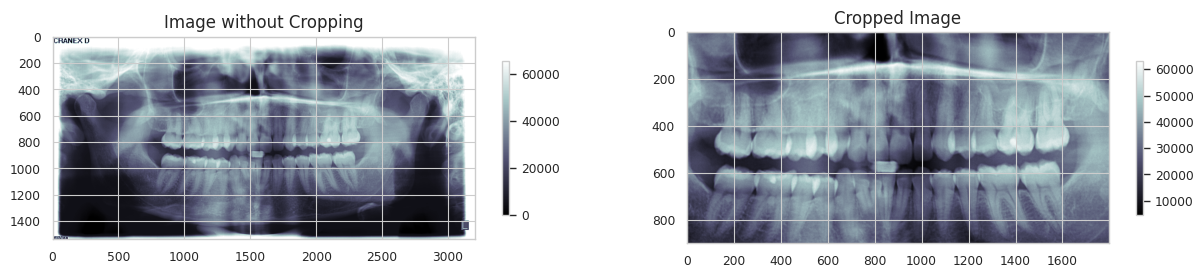

In [ ]:
# cropping the image
# first method: using Keras layer
#cropper = CenterCrop(height=1000, width=2000)
# input shape of CenterCrop should be 3D (unbatched) or 4D (batched) tensor
#image2 = np.expand_dims(image, axis=-1)
#cropped_image = cropper(image2)

# second method
width = 1800
height = 900
y, x = image.shape
startx = x//2 - (width//2)
starty = y//2 - (height//2)
cropped_image = image[starty:starty+height, startx:startx+width]

plt.figure(figsize = (15, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='bone')
plt.colorbar(shrink=0.2)
plt.title("Image without Cropping", fontsize=12)


plt.subplot(1, 2, 2)
plt.imshow(cropped_image, cmap='bone')
plt.colorbar(shrink=0.2)
plt.title("Cropped Image", fontsize=12);

In [ ]:
print(cropped_image.shape)
print(f'Number of unique value: {len(np.unique(cropped_image))}')
print(type(cropped_image))
print(cropped_image.dtype)

(900, 1800)
Number of unique value: 1284
<class 'numpy.ndarray'>
uint16


(450, 900)
Number of unique value: 49182
<class 'numpy.ndarray'>
uint16


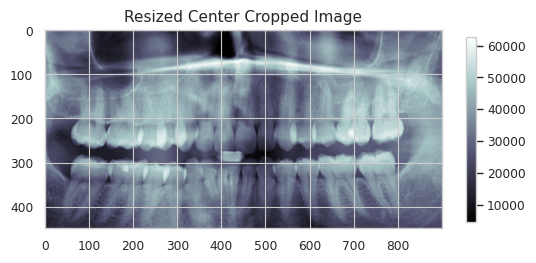

In [ ]:
# Resizing the image
resized_img = ndimage.zoom(cropped_image, (0.5, 0.5), order=1)

print(resized_img.shape)
print(f'Number of unique value: {len(np.unique(resized_img))}')
print(type(resized_img))
print(resized_img.dtype)

plt.imshow(resized_img, cmap='bone')
plt.colorbar(shrink=0.5)
plt.title("Resized Center Cropped Image", fontsize=11);

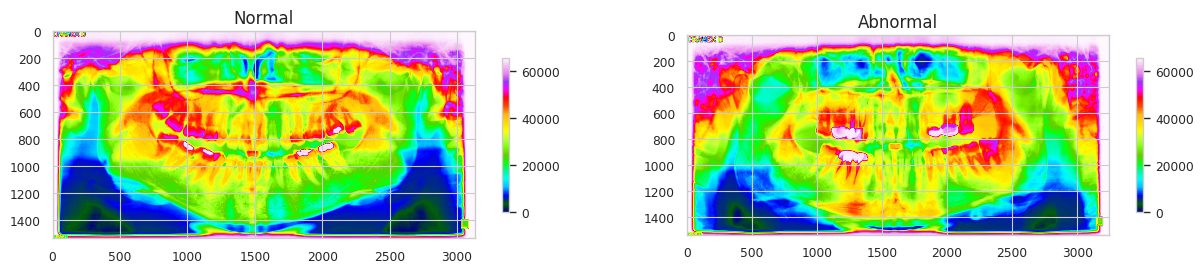

In [ ]:
# normal vs abnormal

# normal
normal_file_path = trn_normal_names[9]
normal_image = pydicom.dcmread(normal_file_path)
n_image = normal_image.pixel_array

# abnormal
abnormal_file_path = trn_abnormal_names[9]
abnormal_image = pydicom.dcmread(abnormal_file_path)
a_image = abnormal_image.pixel_array

plt.figure(figsize = (15, 10))
plt.subplot(1, 2, 1)
plt.imshow(n_image, cmap=plt.cm.gist_ncar)
plt.colorbar(shrink=0.2)
plt.title("Normal", fontsize=12)

plt.subplot(1, 2, 2)
plt.imshow(a_image, cmap=plt.cm.gist_ncar)
plt.colorbar(shrink=0.2)
plt.title("Abnormal", fontsize=12);

## Input Pipeline

### `Option1`: tf.data.Dataset.from_tensor_slices()
If all of input data fits in memory, the simplest way to create a Dataset from them is to convert them to tf.Tensor objects and use Dataset.from_tensor_slices.

In [ ]:
def read_dcm_file(file_path):
    """Read and load DICOM image"""
    # Read file
    dcm_image = pydicom.dcmread(file_path)
    # Get raw data, Numpy ndarray
    image = dcm_image.pixel_array
    return image


def center_crop(image, width, height):
    """Center crop of image"""
    y, x = image.shape
    startx = x//2 - (width//2)
    starty = y//2 - (height//2)
    cropped_image = image[starty:starty+height, startx:startx+width]
    return cropped_image


def normalize(array):
    #"""Normalize the array"""
    normalized_array = array / 2**16
    normalized_array = normalized_array.astype("float32")
    return normalized_array

def expand_channel(array):
    array = np.expand_dims(array, axis=-1)
    array_3_channel = array.repeat(3, axis=-1)
    return array_3_channel

def resize_array(img):
    img = ndimage.zoom(img, (0.4, 0.4, 1), order=1)
    return img


def process_scan(path):
    """Read, crop, normalize, expand, resize array"""
    # Read image
    array = read_dcm_file(path)
    #Crop
    array = center_crop(array, width=1800, height=900)
    # Normalize
    array = normalize(array)
    # Expand channel
    array = expand_channel(array)
    # resize
    array = resize_array(array)
    return array

In [ ]:
path = '/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal/1.2.246.512.1.2.0.4.10835803369629.1963314017.20230101100806.dcm'
array = process_scan(path)
print(type(array))
print(array.shape)

<class 'numpy.ndarray'>
(360, 720, 3)


- Reading the paths of the dcm files from the class directories.

In [ ]:
# Folder "normal" consists of normal samples
normal_dcm_paths = [
    os.path.join(os.getcwd(), "drive/MyDrive/endodontic/data/DICOM_Data/normal", x)
    for x in os.listdir("drive/MyDrive/endodontic/data/DICOM_Data/normal")]

# Folder "abnormal" consists of abnormal samples
abnormal_dcm_paths = [
    os.path.join(os.getcwd(), "drive/MyDrive/endodontic/data/DICOM_Data/abnormal", x)
    for x in os.listdir("drive/MyDrive/endodontic/data/DICOM_Data/abnormal")]

print("Number of DICOM with normal tooth: " + str(len(normal_dcm_paths)))
print("Number of DICOM with abnormal tooth: " + str(len(abnormal_dcm_paths)))

Number of DICOM with normal tooth: 769
Number of DICOM with abnormal tooth: 74


In [ ]:
abnormal_dcm_paths[7]

'/content/drive/MyDrive/endodontic/data/DICOM_Data/abnormal/2.25.95301085161359068904812759023575525475.dcm'

- Building train, validation and test datasets:

- Reading the dcm images from the class directories and assigning labels.
Then, splitting the dataset into train, validation and test subsets.

In [ ]:
# array of arrays
abnormal_images = np.array([process_scan(path) for path in abnormal_dcm_paths])
normal_images = np.array([process_scan(path) for path in normal_dcm_paths])

# Assigning 0 for the normal class and assigning 1 for the abnormal class
abnormal_labels = np.array([1 for _ in range(len(abnormal_images))])
normal_labels = np.array([0 for _ in range(len(normal_images))])

# Splitting data in the ratio 0.8, 0.1, 0.1 for training, validation and test sets respectively. 
x_train = np.concatenate((abnormal_images[:59], normal_images[:615]), axis=0)
y_train = np.concatenate((abnormal_labels[:59], normal_labels[:615]), axis=0)
x_val = np.concatenate((abnormal_images[59:66], normal_images[615:691]), axis=0)
y_val = np.concatenate((abnormal_labels[59:66], normal_labels[615:691]), axis=0)
x_test = np.concatenate((abnormal_images[66:74], normal_images[691:769]), axis=0)
y_test = np.concatenate((abnormal_labels[66:74], normal_labels[691:769]), axis=0)

print(
    "Number of samples in train, validation and test sets are %d, %d and %d."
    % (x_train.shape[0], x_val.shape[0], x_test.shape[0])
)

Number of samples in train, validation and test sets are 674, 83 and 86.


In [ ]:
print(type(x_train))
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)

<class 'numpy.ndarray'>
(674, 360, 720, 3)
(674,)
(83, 360, 720, 3)
(83,)
(86, 360, 720, 3)
(86,)


In [ ]:
y_test

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

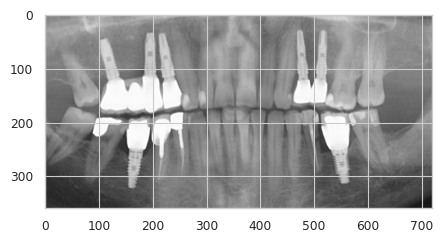

In [ ]:
plt.figure(figsize = (5, 10))
a = x_test[19, :, :, :]
plt.imshow(a)

In [ ]:
x_test[19, :, :, 1]

array([[0.4025879 , 0.40887538, 0.4152656 , ..., 0.33841708, 0.35049346,
        0.33618164],
       [0.41235647, 0.41883838, 0.41627926, ..., 0.34951615, 0.34844   ,
        0.3733116 ],
       [0.40914732, 0.4099263 , 0.39128086, ..., 0.35123217, 0.33404294,
        0.35164487],
       ...,
       [0.08621694, 0.08716265, 0.08766372, ..., 0.08839957, 0.08765078,
        0.08912309],
       [0.08716409, 0.08810848, 0.0888496 , ..., 0.08861721, 0.08934665,
        0.08859952],
       [0.08813477, 0.08812889, 0.08690526, ..., 0.09008496, 0.08936281,
        0.08813477]], dtype=float32)

- Saving the Numpy arrays(train, validation and test)

In [ ]:
# Saving the numpy arrays(train,validation and test) in a single .npz file
np.savez('/content/DICOM_360_720.npz', x_train=x_train, y_train=y_train, x_val=x_val, y_val=y_val, x_test=x_test, y_test=y_test)
# restart runtime to free up memory then load .npz file

- Loading the Numpy arrays(train, validation and test)

In [ ]:
import numpy as np
with np.load('/content/DICOM_360_720.npz', allow_pickle=True) as data:
    x_train = data['x_train']
    y_train = data['y_train']
    x_val = data['x_val']
    y_val = data['y_val'] 
    x_test = data['x_test']
    y_test = data['y_test']

In [ ]:
print(
    "Number of samples in train, validation and test sets are %d, %d and %d."
    % (x_train.shape[0], x_val.shape[0], x_test.shape[0])
)

Number of samples in train, validation and test sets are 674, 83 and 86.


In [ ]:
print(type(x_train))
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)

<class 'numpy.ndarray'>
(674, 360, 720, 3)
(674,)
(83, 360, 720, 3)
(83,)
(86, 360, 720, 3)
(86,)


In [ ]:
y_test

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

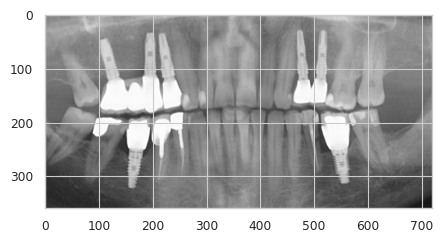

In [ ]:
plt.figure(figsize = (5, 10))
a = x_test[19, :, :, :]
plt.imshow(a)

In [ ]:
x_test[19, :, :, 1]

array([[0.4025879 , 0.40887538, 0.4152656 , ..., 0.33841708, 0.35049346,
        0.33618164],
       [0.41235647, 0.41883838, 0.41627926, ..., 0.34951615, 0.34844   ,
        0.3733116 ],
       [0.40914732, 0.4099263 , 0.39128086, ..., 0.35123217, 0.33404294,
        0.35164487],
       ...,
       [0.08621694, 0.08716265, 0.08766372, ..., 0.08839957, 0.08765078,
        0.08912309],
       [0.08716409, 0.08810848, 0.0888496 , ..., 0.08861721, 0.08934665,
        0.08859952],
       [0.08813477, 0.08812889, 0.08690526, ..., 0.09008496, 0.08936281,
        0.08813477]], dtype=float32)

In [ ]:
# channels are similar to each other
# checking for a sample
print(x_test[19, :, :, 1] - x_test[19, :, :, 2])
print(x_test[19, :, :, 0] - x_test[19, :, :, 0])

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


- Data Loader

In [ ]:
# Defining data loaders(data generators):
# generating tf.data.Dataset objects that can be used to train a model.
train_loader = tf.data.Dataset.from_tensor_slices((x_train, y_train))
validation_loader = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_loader = tf.data.Dataset.from_tensor_slices((x_test, y_test))


batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_loader.shuffle(len(x_train))
    .batch(batch_size)
)
# Data Augmentation
data_augmentation = tf.keras.Sequential([layers.RandomFlip("horizontal_and_vertical"),])
                                                 #layers.RandomRotation(0.1),
                                                 #layers.RandomZoom(0.1),])
# Applying `data_augmentation` only to the train_dataset
train_dataset = train_dataset.map(lambda img, label: (data_augmentation(img), label),
                         num_parallel_calls=AUTOTUNE)

# Prefetching samples in GPU memory helps maximize GPU utilization.
# Dataset.prefetch overlaps data preprocessing and model execution while training.
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)


validation_dataset = (
    validation_loader.shuffle(len(x_val))
    .batch(batch_size)
    .prefetch(buffer_size=AUTOTUNE)
)

test_dataset = (
    test_loader.batch(batch_size)
    .prefetch(buffer_size=AUTOTUNE)
)


# checking data type of train_ds
print(type(train_dataset))

for image_batch, labels_batch in train_dataset:
   print(image_batch.shape)
   print(type(image_batch))
   print(labels_batch.shape)
   print(type(labels_batch))
   break

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
(32, 360, 720, 3)
<class 'tensorflow.python.framework.ops.EagerTensor'>
(32,)
<class 'tensorflow.python.framework.ops.EagerTensor'>


Exception ignored in: <function Executor.__del__ at 0x7f178dd30c10>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/tensorflow/python/eager/executor.py", line 46, in __del__
    self.wait()
  File "/usr/local/lib/python3.10/dist-packages/tensorflow/python/eager/executor.py", line 65, in wait
    pywrap_tfe.TFE_ExecutorWaitForAllPendingNodes(self._handle)
tensorflow.python.framework.errors_impl.OutOfRangeError: End of sequence


Dimension of the image is: (360, 720, 3)


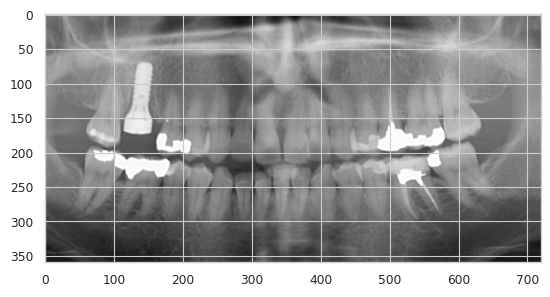

In [ ]:
# visualizing an augmented image
# taking one batch
data = train_dataset.take(1)
images, labels = list(data)[0]
images = images.numpy()
image = images[0]
print("Dimension of the image is:", image.shape)
plt.imshow(image[:, :, 0], cmap="gray");

### `Option2`: tf.keras.utils.Sequence
Creating custom data generator using tf.keras.utils.Sequence when we don't want to load the entire dataset at once.
 
Preprocessing inside the data generator :

- Splitting DICOM_Data folder(that contains 2 subfolders: normal and abnormal) to 3 folders train, validation and test that each of these also includes 2 subfolders: normal and abnormal

In [ ]:
# using splitfolders package for splitting 'DICOM_Data' folder to 'splitted_data' folder,
# 'splitted_data' folder contains 3 subfolders train, test and val 
# 80% for train, 10% for development and 10% for test
DATA_DIRECT = '/content/drive/MyDrive/endodontic/data/DICOM_Data/'
output_dir = '/content/splitted_data/'
splitfolders.ratio(DATA_DIRECT, output=output_dir, seed=1, ratio=(.8, .1, .1),
                   group_prefix=None, move=False)


Copying files: 836 files [10:20,  1.32s/ files]
Copying files: 837 files [10:22,  1.30s/ files]
Copying files: 838 files [10:23,  1.30s/ files]
Copying files: 839 files [10:26,  1.87s/ files]
Copying files: 840 files [10:27,  1.68s/ files]
Copying files: 841 files [10:30,  1.84s/ files]
Copying files: 842 files [10:31,  1.65s/ files]
Copying files: 843 files [10:35,  1.33 files/s]


In [ ]:
os.listdir(output_dir)

['train', 'val', 'test']

In [ ]:
print(os.listdir('splitted_data/test'))
print(os.listdir('splitted_data/train'))
print(os.listdir('splitted_data/val'))

['abnormal', 'normal']
['abnormal', 'normal']
['abnormal', 'normal']


In [ ]:
# class-imbalanced dataset: ---> train, validation and test sets should have same data distribution
print('Total training normal images :', len(os.listdir('splitted_data/train/normal')))
print('Total training abnormal images :', len(os.listdir('splitted_data/train/abnormal')))

print('Total validation normal images :', len(os.listdir('splitted_data/val/normal')))
print('Total validation abnormal images :', len(os.listdir('splitted_data/val/abnormal')))

print('Total test normal images :', len(os.listdir('splitted_data/test/normal')))
print('Total test abnormal images :', len(os.listdir('splitted_data/test/abnormal')))

Total training normal images : 615
Total training abnormal images : 59
Total validation normal images : 76
Total validation abnormal images : 7
Total test normal images : 78
Total test abnormal images : 8


- Reading the paths of the dcm files from the class directories and then creating a dictionary that contains keys: train, validation, and test . Values of the dictionary are list of training SOPInstanceUIDs, validation SOPInstanceUIDs, and test SOPInstanceUIDs respectively.

In [ ]:
# training paths
train_normal_paths = [
    os.path.join(os.getcwd(), "splitted_data/train/normal", x)
    for x in os.listdir("splitted_data/train/normal")]

train_abnormal_paths = [
    os.path.join(os.getcwd(), "splitted_data/train/abnormal", x)
    for x in os.listdir("splitted_data/train/abnormal")]

# merging two lists: train_normal_paths and train_abnormal_paths using + operator
train_paths = train_normal_paths + train_abnormal_paths
print(len(train_paths))


# validation paths
validation_normal_paths = [
    os.path.join(os.getcwd(), "splitted_data/val/normal", x)
    for x in os.listdir("splitted_data/val/normal")]

validation_abnormal_paths = [
    os.path.join(os.getcwd(), "splitted_data/val/abnormal", x)
    for x in os.listdir("splitted_data/val/abnormal")]

# merging two lists: validation_normal_paths and validation_abnormal_paths using + operator
validation_paths = validation_normal_paths + validation_abnormal_paths
print(len(validation_paths))


# test paths
test_normal_paths = [
    os.path.join(os.getcwd(), "splitted_data/test/normal", x)
    for x in os.listdir("splitted_data/test/normal")]

test_abnormal_paths = [
    os.path.join(os.getcwd(), "splitted_data/test/abnormal", x)
    for x in os.listdir("splitted_data/test/abnormal")]

# merging two lists: test_normal_paths and test_abnormal_paths using + operator
test_paths = test_normal_paths + test_abnormal_paths
print(len(test_paths))

674
83
86


In [ ]:
test_abnormal_paths

['/content/splitted_data/test/abnormal/2.25.46798094416819654121318669807117652003.dcm',
 '/content/splitted_data/test/abnormal/1.2.246.512.1002.4046933793.1329774659.16304224041255670174.dcm',
 '/content/splitted_data/test/abnormal/1.2.246.512.1002.1595235956.1216394916.17313991026152031393.dcm',
 '/content/splitted_data/test/abnormal/1.2.246.512.1.2.0.4.298654083137790.16721130216.20230104115701.dcm',
 '/content/splitted_data/test/abnormal/2.25.335154639171226728750609442359772190378.dcm',
 '/content/splitted_data/test/abnormal/1.2.246.512.1002.1969900632.1166216652.907076632196724144.dcm',
 '/content/splitted_data/test/abnormal/2.25.305861492438344748144578306421271906759.dcm',
 '/content/splitted_data/test/abnormal/2.25.98835785365870433323978690584106362345.dcm']

In [ ]:
partition = {'train': train_paths, 'validation': validation_paths, 'test': test_paths}

In [ ]:
# Creating dictionary where for each SOPInstanceUID of the dataset, the associated label is given by label[SOPInstanceUID]
#df1 = pd.read_csv(label_dir1)
#df1['Label'] = df1['Label'].replace({ 'normal':0, 'abnormal':1 })
#label_1 = dict([ (i, j) for i, j in zip(df1.SOPInstanceUID, df1.Label) ])
#print(label_1)
#print(len(label_1))

#df2 = pd.read_csv(label_dir2)
#df2['Label'] = df2['Label'].replace({ 'normal':0, 'abnormal':1 })
#label_2 = dict([ (i, j) for i, j in zip(df2.SOPInstanceUID, df2.Label) ])
#print(label_2)
#print(len(label_2))

# merging two dictionaries: label_1 and label_2 using | operator
#labels = label_1 | label_2
#print(labels)
#print(len(labels))

In [ ]:
# creating custom data generator that inherits tf.keras.utils.Sequence 
class DICOMDataGenerator(tf.keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_paths, batch_size=8, crop_height=1000, crop_width=2000, n_channels=3,
                 zoom_factor_height=0.5, zoom_factor_width=0.5,
                 mode='fit', label_mode='binary',
                 n_classes=2, shuffle=True, random_state=1):
        'Initialization'
        self.crop_height = crop_height
        self.crop_width = crop_width
        self.zoom_factor_height = zoom_factor_height
        self.zoom_factor_width = zoom_factor_width
        self.batch_size = batch_size
        self.list_paths = list_paths
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.mode = mode
        self.random_state = random_state
        self.label_mode = label_mode

        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch, so that the model sees the training samples at most once per epoch.'
        return int(np.floor(len(self.list_paths) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of paths
        list_paths_batch = [self.list_paths[k] for k in indexes]

        # Generate data
        X = self.__generate_X(list_paths_batch)

        if self.mode == 'fit':
            y = self.__generate_y(list_paths_batch)
            return X, y
        
        elif self.mode == 'predict':
            return X

        else:
            raise AttributeError('The mode parameter should be set to "fit" or "predict".')


    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_paths))
        if self.shuffle == True:
            np.random.seed(self.random_state)
            np.random.shuffle(self.indexes)


    def __generate_X(self, list_paths_batch):
        'Generates data containing batch_size samples' 
        # X : (n_samples, crop_height/zoom_factor_height, crop_width/zoom_factor_width, n_channels)
        # Initialization
        h = self.crop_height * self.zoom_factor_height
        w = self.crop_width * self.zoom_factor_width
        X = np.empty((self.batch_size, int(h), int(w), self.n_channels))
        
        # Generate data
        for i, path in enumerate(list_paths_batch):
            # read, crop, normalize, expand, resize array
            # read image
            array = self.__read_dcm_file(path)
            # crop
            array = self.__center_crop(array, self.crop_width, self.crop_height)
            # normalize
            array = self.__normalize(array)
            # expand channel
            array = self.__expand_channel(array)
            # resize 
            array = self.__resize_array(array, self.zoom_factor_height, self.zoom_factor_width)

            # Store sample
            X[i,] = array

        return X

    def __generate_y(self, list_paths_batch):
        # Initialization
        y = np.empty((self.batch_size), dtype=np.float32)
        
        for i, path in enumerate(list_paths_batch):
            # store class 
            if 'abnormal' in path:
              y[i] = 1
            else:
              y[i] = 0
        
        if self.label_mode == 'binary':
            return y
        
        elif self.label_mode == 'categorical':
            return tf.keras.utils.to_categorical(y, num_classes=self.n_classes)

        else:
            raise AttributeError('The label_mode parameter should be set to "binary" or "categorical".')


    def __read_dcm_file(self, file_path):
      """Read and load DICOM image"""
      # Read file
      dcm_image = pydicom.dcmread(file_path)
      # Get raw data, Numpy ndarray
      image = dcm_image.pixel_array
      return image

    def __center_crop(self, image, crop_width, crop_height):
      """Center crop of image"""
      y, x = image.shape
      startx = x//2 - (crop_width//2)
      starty = y//2 - (crop_height//2)
      cropped_image = image[starty:starty+crop_height, startx:startx+crop_width]
      return cropped_image

    def __normalize(self, array):
      """Normalize the array"""
      normalized_array = array / 2**16
      normalized_array = normalized_array.astype("float32")
      return normalized_array

    def __expand_channel(self, array):
      array = np.expand_dims(array, axis=-1)
      array_3_channel = array.repeat(3, axis=-1)
      return array_3_channel

    def __resize_array(self, img, zoom_factor_height, zoom_factor_width):
      img = ndimage.zoom(img, (zoom_factor_height, zoom_factor_width, 1), order=1)
      return img


In [ ]:
# Defining data loaders(data generators):
BATCH_SIZE = 8
HEIGHT = 1000
WIDTH = 2000

train_loader = DICOMDataGenerator(partition['train'], batch_size=BATCH_SIZE, crop_height=HEIGHT, crop_width=WIDTH,
                                  zoom_factor_height=0.5, zoom_factor_width=0.5, label_mode='binary',
                                  n_channels = 3, n_classes=2, shuffle=True, mode='fit', random_state=1)

validation_loader = DICOMDataGenerator(partition['validation'], batch_size=BATCH_SIZE, crop_height=HEIGHT, crop_width=WIDTH,
                                       zoom_factor_height=0.5, zoom_factor_width=0.5, label_mode='binary',
                                       n_channels = 3, n_classes=2, shuffle=True, mode='fit', random_state=1)

test_loader = DICOMDataGenerator(partition['test'], batch_size=BATCH_SIZE, crop_height=HEIGHT, crop_width=WIDTH,
                                 zoom_factor_height=0.5, zoom_factor_width=0.5, label_mode='binary',
                                 n_channels = 3, n_classes=2, shuffle=True, mode='fit', random_state=1)


# checking data type of data generatros; for example: train_loader
print(type(train_loader)) 

for image_batch, labels_batch in train_loader:
   print(f'Image Batch Shape = {image_batch.shape}')
   print('min=%.3f, max=%.3f' % (image_batch.min(), image_batch.max()))
   print(type(image_batch))
   print(image_batch.dtype)
 
   print('-----'*5)

   print(f'Labels Batch Shape = {labels_batch.shape}')
   print('min=%.3f, max=%.3f' % (labels_batch.min(), labels_batch.max()))
   print(type(labels_batch))
   print(labels_batch.dtype)
   print(labels_batch)
   break


<class '__main__.DICOMDataGenerator'>
Image Batch Shape = (8, 500, 1000, 3)
min=0.053, max=1.000
<class 'numpy.ndarray'>
float64
-------------------------
Labels Batch Shape = (8,)
min=0.000, max=1.000
<class 'numpy.ndarray'>
float32
[0. 0. 0. 0. 0. 0. 1. 0.]


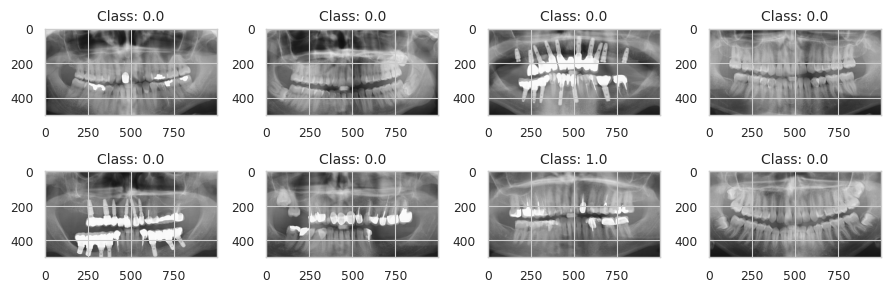

In [ ]:
# visualizing several samples from one batch
plt.figure(figsize=(9, 3))
for i in range(0, 8):
    plt.subplot(2, 4, i+1)
    for X_batch, y_batch in train_loader:
        image = X_batch[i]
        plt.imshow(image)
        plt.title(f"Class: {y_batch[i]}", fontsize=10)
        break
plt.tight_layout()
plt.show()

### `Option3`: tf.keras.utils.Sequence
Creating custom data generator using tf.keras.utils.Sequence when we don't want to load the entire dataset at once. 

Applying data generator to preprocessed data:

In [6]:
def read_dcm_file(file_path):
    """Read and load DICOM image"""
    # Read file
    dcm_image = pydicom.dcmread(file_path)
    # Get raw data, Numpy ndarray
    image = dcm_image.pixel_array
    return image


def center_crop(image, width, height):
    """Center crop of image"""
    y, x = image.shape
    startx = x//2 - (width//2)
    starty = y//2 - (height//2)
    cropped_image = image[starty:starty+height, startx:startx+width]
    return cropped_image


def normalize(array):
    #"""Normalize the array"""
    normalized_array = array / 2**16
    normalized_array = normalized_array.astype("float32")
    return normalized_array

def expand_channel(array):
    array = np.expand_dims(array, axis=-1)
    array_3_channel = array.repeat(3, axis=-1)
    return array_3_channel

def resize_array(img):
    img = ndimage.zoom(img, (0.8, 0.8, 1), order=3)
    return img


def process_scan(path):
    """Read, crop, normalize, expand, resize array"""
    # Read image
    array = read_dcm_file(path)
    #Crop
    array = center_crop(array, width=1800, height=900)
    # Normalize
    array = normalize(array)
    # Expand channel
    array = expand_channel(array)
    # resize
    array = resize_array(array)
    return array

In [9]:
# Folder "normal" consists of normal samples
normal_dcm_paths = [
    os.path.join(os.getcwd(), "drive/MyDrive/endodontic/data/DICOM_Data/normal", x)
    for x in os.listdir("drive/MyDrive/endodontic/data/DICOM_Data/normal")]

# Folder "abnormal" consists of abnormal samples
abnormal_dcm_paths = [
    os.path.join(os.getcwd(), "drive/MyDrive/endodontic/data/DICOM_Data/abnormal", x)
    for x in os.listdir("drive/MyDrive/endodontic/data/DICOM_Data/abnormal")]

print("Number of DICOM with normal tooth: " + str(len(normal_dcm_paths)))
print("Number of DICOM with abnormal tooth: " + str(len(abnormal_dcm_paths)))

Number of DICOM with normal tooth: 1264
Number of DICOM with abnormal tooth: 116


- Saving NumPy Arrays to .npy Files

In [31]:
!rm -rf /content/DICOM_Data
!rm -rf /content/splitted_data

In [10]:
# creating 'DICOM_Data' folder
os.mkdir('/content/DICOM_Data')
# creating 2 folders in 'DICOM_Data' folder: one for normal and another for abnormal class
os.mkdir('/content/DICOM_Data/normal')
os.mkdir('/content/DICOM_Data/abnormal')

 abnorml samples(1:96)

In [11]:
# array of arrays
abnormal_images = np.array([process_scan(path) for path in abnormal_dcm_paths[0:96]])
print(abnormal_images.shape)

# transfering abnormal arrays to folder abnormal
for i in range(abnormal_images.shape[0]):
  data = abnormal_images[i]
  np.save(f'/content/DICOM_Data/abnormal/abnormal{i}.npy', data)

# now, we have data on disk. Thus:
# we can free up memory by deleting variables that are not needed any more
del abnormal_images

# restart runtime to free up RAM

(96, 720, 1440, 3)


first part of normal samples(1:200)

In [ ]:
# array of arrays
normal_images = np.array([process_scan(path) for path in normal_dcm_paths[0:200] ])
print(normal_images.shape)

# transfering normal arrays to folder normal
for i in range(normal_images.shape[0]):
  data = normal_images[i]
  np.save(f'/content/DICOM_Data/normal/normal{i}.npy', data)

del normal_images

(200, 720, 1440, 3)


second part of normal samples: 201:400

In [ ]:
# Saving NumPy Arrays to .npy Files
normal_images_2 = np.array([process_scan(path) for path in normal_dcm_paths[200:400] ])
print(normal_images_2.shape)

# transfering normal arrays to folder normal
for i in range(normal_images_2.shape[0]):
  data = normal_images_2[i]
  np.save(f'/content/DICOM_Data/normal/normal_s{i}.npy', data)

# free up memory
del normal_images_2

#restart runtime

(200, 720, 1440, 3)


third part of normal samples: 401:600

In [ ]:
# Saving NumPy Arrays to .npy Files
normal_images_3 = np.array([process_scan(path) for path in normal_dcm_paths[400:600] ])
print(normal_images_3.shape)

# transfering normal arrays to folder normal
for i in range(normal_images_3.shape[0]):
  data = normal_images_3[i]
  np.save(f'/content/DICOM_Data/normal/normal_t{i}.npy', data)

# free up memory
del normal_images_3

#restart runtime

(200, 720, 1440, 3)


fourth part of normal samples: 601:800

In [ ]:
# Saving NumPy Arrays to .npy Files
normal_images_4 = np.array([process_scan(path) for path in normal_dcm_paths[600:800] ])
print(normal_images_4.shape)

# transfering normal arrays to folder normal
for i in range(normal_images_4.shape[0]):
  data = normal_images_4[i]
  np.save(f'/content/DICOM_Data/normal/normal_f{i}.npy', data)

# free up memory
del normal_images_4

# restart runtime

fifth part of normal samples: 801:1000

In [ ]:
# Saving NumPy Arrays to .npy Files
normal_images_5 = np.array([process_scan(path) for path in normal_dcm_paths[800:1000] ])
print(normal_images_5.shape)

# transfering normal arrays to folder normal
for i in range(normal_images_5.shape[0]):
  data = normal_images_5[i]
  np.save(f'/content/DICOM_Data/normal/normal_fi{i}.npy', data)

# free up memory
del normal_images_5

# restart runtime

`Validation Set`:
sixth part of normal samples(1001:1164) and abnormal samples(97:106)

In [48]:
# Saving NumPy Arrays to .npy Files
abnormal_images_2 = np.array([process_scan(path) for path in abnormal_dcm_paths[96:106]])
print(abnormal_images_2.shape)

# transfering abnormal arrays to folder abnormal
for i in range(abnormal_images_2.shape[0]):
  data = abnormal_images_2[i]
  np.save(f'/content/DICOM_Data/abnormal/abnormal_s{i}.npy', data)

# free up memory
del abnormal_images_2

(10, 720, 1440, 3)


In [13]:
# Saving NumPy Arrays to .npy Files
normal_images_6 = np.array([process_scan(path) for path in normal_dcm_paths[1000:1164] ])
print(normal_images_6.shape)

# transfering normal arrays to folder normal
for i in range(normal_images_6.shape[0]):
  data = normal_images_6[i]
  np.save(f'/content/DICOM_Data/normal/normal_si{i}.npy', data)


# free up memory
del normal_images_6

# restart runtime

(164, 720, 1440, 3)


`Test Set`: seventh part of normal samples(1165:1264) and abnormal samples(107:116)

In [12]:
# Saving NumPy Arrays to .npy Files
abnormal_images_3 = np.array([process_scan(path) for path in abnormal_dcm_paths[106:116]])
print(abnormal_images_3.shape)

# transfering abnormal arrays to folder abnormal
for i in range(abnormal_images_3.shape[0]):
  data = abnormal_images_3[i]
  np.save(f'/content/DICOM_Data/abnormal/abnormal_t{i}.npy', data)

# free up memory
del abnormal_images_3

(10, 720, 1440, 3)


In [13]:
# Saving NumPy Arrays to .npy Files
normal_images_7 = np.array([process_scan(path) for path in normal_dcm_paths[1164:1264] ])
print(normal_images_7.shape)

# transfering normal arrays to folder normal
for i in range(normal_images_7.shape[0]):
  data = normal_images_7[i]
  np.save(f'/content/DICOM_Data/normal/normal_seven{i}.npy', data)


# free up memory
del normal_images_7

# restart runtime

(100, 720, 1440, 3)


In [14]:
# checking number of samples
print(len(os.listdir('/content/DICOM_Data/abnormal')))
print(len(os.listdir('/content/DICOM_Data/normal')))

106
100


- Splitting DICOM_Data folder(that contains 2 subfolders: normal and abnormal) to 3 folders train, validation and test that each of these also includes 2 subfolders: normal and abnormal

In [15]:
# using splitfolders package for splitting 'DICOM_Data' folder to 'splitted_data' folder,
# 'splitted_data' folder contains 3 subfolders train, test and val 
# 80% for train, 10% for development and 10% for test
DATA_DIRECT = '/content/DICOM_Data/'
output_dir = '/content/splitted_data/'
splitfolders.ratio(DATA_DIRECT, output=output_dir, seed=29, ratio=(1, 0, 0),
                   group_prefix=None, move=True)

Copying files: 206 files [00:00, 10993.82 files/s]


In [ ]:
print(os.listdir('splitted_data'))
print(os.listdir('splitted_data/test'))
print(os.listdir('splitted_data/train'))
print(os.listdir('splitted_data/val'))

['test', 'train', 'val']
['normal', 'abnormal']
['normal', 'abnormal']
['normal', 'abnormal']


In [16]:
# class-imbalanced dataset: ---> train, validation and test sets should have same data distribution
print('Total training normal images :', len(os.listdir('splitted_data/train/normal')))
print('Total training abnormal images :', len(os.listdir('splitted_data/train/abnormal')))

print('Total validation normal images :', len(os.listdir('splitted_data/val/normal')))
print('Total validation abnormal images :', len(os.listdir('splitted_data/val/abnormal')))

print('Total test normal images :', len(os.listdir('splitted_data/test/normal')))
print('Total test abnormal images :', len(os.listdir('splitted_data/test/abnormal')))

Total training normal images : 100
Total training abnormal images : 106
Total validation normal images : 0
Total validation abnormal images : 0
Total test normal images : 0
Total test abnormal images : 0


In [ ]:
!mv /content/splitted_data/test/abnormal/abnormal72.npy /content/splitted_data/val/abnormal

- Reading the paths of the dcm files from the class directories and then creating a dictionary that contains keys: train, validation, and test . Values of the dictionary are list of training SOPInstanceUIDs, validation SOPInstanceUIDs, and test SOPInstanceUIDs respectively.

In [17]:
# training paths
train_normal_paths = [
    os.path.join(os.getcwd(), "splitted_data/train/normal", x)
    for x in os.listdir("splitted_data/train/normal")]

train_abnormal_paths = [
    os.path.join(os.getcwd(), "splitted_data/train/abnormal", x)
    for x in os.listdir("splitted_data/train/abnormal")]

# merging two lists: train_normal_paths and train_abnormal_paths using + operator
train_paths = train_normal_paths + train_abnormal_paths
print(len(train_paths))


# validation paths
validation_normal_paths = [
    os.path.join(os.getcwd(), "splitted_data/val/normal", x)
    for x in os.listdir("splitted_data/val/normal")]

validation_abnormal_paths = [
    os.path.join(os.getcwd(), "splitted_data/val/abnormal", x)
    for x in os.listdir("splitted_data/val/abnormal")]

# merging two lists: validation_normal_paths and validation_abnormal_paths using + operator
validation_paths = validation_normal_paths + validation_abnormal_paths
print(len(validation_paths))


# test paths
test_normal_paths = [
    os.path.join(os.getcwd(), "splitted_data/test/normal", x)
    for x in os.listdir("splitted_data/test/normal")]

test_abnormal_paths = [
    os.path.join(os.getcwd(), "splitted_data/test/abnormal", x)
    for x in os.listdir("splitted_data/test/abnormal")]

# merging two lists: test_normal_paths and test_abnormal_paths using + operator
test_paths = test_normal_paths + test_abnormal_paths
print(len(test_paths))

206
0
0


In [ ]:
test_abnormal_paths

['/content/splitted_data/test/abnormal/abnormal101.npy',
 '/content/splitted_data/test/abnormal/abnormal108.npy',
 '/content/splitted_data/test/abnormal/abnormal25.npy',
 '/content/splitted_data/test/abnormal/abnormal91.npy',
 '/content/splitted_data/test/abnormal/abnormal56.npy',
 '/content/splitted_data/test/abnormal/abnormal32.npy',
 '/content/splitted_data/test/abnormal/abnormal38.npy',
 '/content/splitted_data/test/abnormal/abnormal41.npy',
 '/content/splitted_data/test/abnormal/abnormal11.npy',
 '/content/splitted_data/test/abnormal/abnormal83.npy',
 '/content/splitted_data/test/abnormal/abnormal98.npy',
 '/content/splitted_data/test/abnormal/abnormal59.npy',
 '/content/splitted_data/test/abnormal/abnormal103.npy']

In [18]:
partition = {'train': train_paths, 'validation': validation_paths, 'test': test_paths}

In [19]:
# creating a custom data generator that inherits from tf.keras.utils.Sequence class
class DICOMDataGenerator(tf.keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_paths, batch_size=8, n_channels=3, height=720, width=1440,
                 mode='fit', label_mode='binary',
                 n_classes=2, shuffle=True, random_state=1):
        'Initialization'
        self.batch_size = batch_size
        self.list_paths = list_paths
        self.n_channels = n_channels
        self.height = height
        self.width = width
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.mode = mode
        self.random_state = random_state
        self.label_mode = label_mode

        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch, so that the model sees the training samples at most once per epoch.'
        return int(np.floor(len(self.list_paths) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of paths
        list_paths_batch = [self.list_paths[k] for k in indexes]

        # Generate data
        X = self.__generate_X(list_paths_batch)

        if self.mode == 'fit':
            y = self.__generate_y(list_paths_batch)
            return X, y
        
        elif self.mode == 'predict':
            return X

        else:
            raise AttributeError('The mode parameter should be set to "fit" or "predict".')

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_paths))
        if self.shuffle == True:
            np.random.seed(self.random_state)
            np.random.shuffle(self.indexes)


    def __generate_X(self, list_paths_batch):
        'Generates data containing batch_size samples' 
        # X : (n_samples, height, width, n_channels)
        # Initialization
        X = np.empty((self.batch_size, self.height, self.width, self.n_channels))
        
        # Generate data
        for i, path in enumerate(list_paths_batch):
            # read image
            array = np.load(path)
            # Store sample
            X[i,] = array

        return X

    def __generate_y(self, list_paths_batch):
        # Initialization
        y = np.empty((self.batch_size), dtype=np.float32)
        
        for i, path in enumerate(list_paths_batch):
            # store class 
            if 'abnormal' in path:
              y[i] = 1
            else:
              y[i] = 0
        
        if self.label_mode == 'binary':
            return y
        
        elif self.label_mode == 'categorical':
            return tf.keras.utils.to_categorical(y, num_classes=self.n_classes)

        else:
            raise AttributeError('The label_mode parameter should be set to "binary" or "categorical".')


In [20]:
# Defining data loaders(data generators):
BATCH_SIZE = 4
H = 720
W = 1440

train_loader = DICOMDataGenerator(partition['train'], batch_size=BATCH_SIZE, height=H, width=W,
                                   label_mode='binary', n_channels = 3, n_classes=2,
                                   shuffle=True, mode='fit', random_state=1)

validation_loader = DICOMDataGenerator(partition['validation'], batch_size=BATCH_SIZE, height=H, width=W,
                                       label_mode='binary',n_channels = 3, n_classes=2,
                                       shuffle=True, mode='fit', random_state=1)

test_loader = DICOMDataGenerator(partition['test'], batch_size=4, height=H, width=W,
                                 label_mode='binary', n_channels = 3, n_classes=2,
                                 shuffle=True, mode='fit', random_state=1)


# checking data type of data generatros; for example: train_loader
print(type(train_loader)) 

for image_batch, labels_batch in train_loader:
   print(f'Image Batch Shape = {image_batch.shape}')
   print('min=%.3f, max=%.3f' % (image_batch.min(), image_batch.max()))
   print(type(image_batch))
   print(image_batch.dtype)
 
   print('-----'*5)

   print(f'Labels Batch Shape = {labels_batch.shape}')
   print('min=%.3f, max=%.3f' % (labels_batch.min(), labels_batch.max()))
   print(type(labels_batch))
   print(labels_batch.dtype)
   print(labels_batch)
   break

<class '__main__.DICOMDataGenerator'>
Image Batch Shape = (4, 720, 1440, 3)
min=-0.001, max=1.011
<class 'numpy.ndarray'>
float64
-------------------------
Labels Batch Shape = (4,)
min=0.000, max=1.000
<class 'numpy.ndarray'>
float32
[0. 0. 1. 0.]


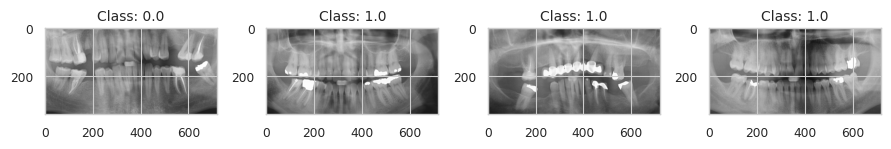

In [ ]:
# visualizing several samples from one batch
plt.figure(figsize=(9, 3))
for i in range(0, 4):
    plt.subplot(1, 4, i+1)
    for X_batch, y_batch in train_loader:
        image = X_batch[i]
        plt.imshow(image)
        plt.title(f"Class: {y_batch[i]}", fontsize=10)
        break
plt.tight_layout()
plt.show()